# Maskinlæring

Til maskinlæringsfilen burker jeg begge excel-filene. Jeg "Joiner" de sammen med "mtid_vf" og "periode" kolonnene.

## importering av bibliotek og dataprep

In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from pycaret.utils import version
from pycaret.classification import *

In [3]:
fil = pd.read_excel('2020 Vannforsyningssystem_analyse drikkevann.xlsx')

#### Eksempler på data (topp og bunn)

In [4]:
fil.head()

,mtid_vf,periode,analysetype,ant_krav,ant_analyser,ant_avvik
0,Z0704301334229761190PVHZK,2011,Smak,4.0,4.0,0.0
1,Z0704301334229761190PVHZK,2011,Koliforme bakterier,12.0,12.0,1.0
2,Z0704301334229761190PVHZK,2011,"Clostridium perfringens (inkl, sporer)",5.0,5.0,0.0
3,Z0704301334229761190PVHZK,2011,Kimtall 22° C,12.0,12.0,0.0
4,Z0704301334229761190PVHZK,2011,Lukt,4.0,4.0,0.0


In [5]:
fil.tail()

,mtid_vf,periode,analysetype,ant_krav,ant_analyser,ant_avvik
355228,Z2101221442492532025NVOFX,2020,Turbiditet,7.0,7.0,0.0
355229,Z2101221442492532025NVOFX,2020,pH,7.0,7.0,0.0
355230,Z2101221442492532025NVOFX,2020,Intestinale enterokokker,9.0,9.0,0.0
355231,Z2101221442492532025NVOFX,2020,Farge,7.0,7.0,0.0
355232,Z2101221442492532025NVOFX,2020,E. Coli,16.0,16.0,0.0


#### Beskrivelse av data verdier

In [6]:
fil.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 355233 entries, 0 to 355232
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   mtid_vf       355233 non-null  object 
 1   periode       355233 non-null  int64  
 2   analysetype   355233 non-null  object 
 3   ant_krav      341469 non-null  float64
 4   ant_analyser  354688 non-null  float64
 5   ant_avvik     347883 non-null  float64
dtypes: float64(3), int64(1), object(2)
memory usage: 16.3+ MB


In [7]:
print("Andelen data som ikke innholder manglende eller korrupt data: {:0.2f}%".format(341469/355233*100))

Andelen data som ikke innholder manglende eller korrupt data: 96.13%


Vi ser fra dataen over at antall ikke-null er signifikant. Resten av dataen er i riktig Dtype format.

Siden vi er interessert i å trene en ML-modeller, er det naturlig å ikke justere på dataen slik at det ikke blir biases i modellen.

Velger derfor å droppe nullverdier

In [8]:
fil = fil.dropna()
print(f"Antall data i filen etter å ha fjernet NAN verdiene: {len(fil)}")

Antall data i filen etter å ha fjernet NAN verdiene: 337645


### Undersøker de forskjellige variablene. (Feature engineering)

Identifikatoren for vannsystemene er en variabel som er nyttig for kobling mellom datasettene. Det samme gjelder periode. Dette for å få aktivitet og produksjon fra "2020 Vannforsyningssystem data"-filen.

Men disse to variablene vil ikke bli brukt i modelleringen.

##### Antall krav

Når det gjelder antall krav, kan det tenkes at dette blir bestemt etter en skal bestemme om det skal utføres en kontroll. Dermed, er det rimelig å tenke at denne variablen er noe som bør predikeres gitt noen variabler (egenskaper) ved vannverket. Det er også verdt å bemerke seg at krav til antall prøver og antallet prøver som blir tatt er ikke alltid like. 

Jeg konkluderer med at det er ikke naturlig å burke denne variablen som en forklarings variabel


In [9]:
print(f"Antall ganger det ble utført like mange analyser som kravet: {len(fil.loc[fil.ant_krav == fil.ant_analyser])}")

Antall ganger det ble utført like mange analyser som kravet: 238653


##### Antall analyser

Antall analyser er en variabel som jeg instinktivt tenker skal være med. Argumentet er at det er ikke så urimelig å anta at avvikene øker med antall analyer. En intuitiv måte å tenke på dette er å tenke ekstreme tilfeller (så kalt corner cases).

Blir det tatt null analyser, vil det ikke være noen avvik. Når antallet analyser øker, vil sansynligheten for å oppdage avvik øke.

Men, i en reell modell, ville jeg vært forsiktig med å ta med denne variablen. Grunnen til det er at det bærer noe bias i modellen ved å ha den med som en forklaringsvariabel.

#### Undersøker variabelen analysetype

In [10]:
parametere = fil.analysetype.unique()
print(f"Antall parametere: {len(parametere)}")
print()
print(parametere)

Antall parametere: 83

['Smak' 'Koliforme bakterier' 'Clostridium perfringens (inkl, sporer)'
 'Kimtall 22° C' 'Lukt' 'Turbiditet' 'Intestinale enterokokker' 'pH'
 'E. Coli' 'Farge' 'Ledningsevne' 'Ammonium' 'Trihalometaner - total'
 'Jern' 'Bly' 'Magnesium' 'Polyaromatiske hydrokarboner (PAH)' 'Aluminium'
 'Kalsium' 'Radon' 'Kadmium' 'Glykoler' 'Sulfat' 'Nitrat' 'Nitritt'
 'Mangan' 'Bor' 'Krom' 'Nikkel' 'Kvikksølv' 'Natrium' 'Kobber' 'Fluorid'
 'Selen' 'Klorid' 'Totalt organisk karbon (TOC)' 'Cyanid'
 'Tetrakloreten og trikloreten' 'Plantevernmidler - total'
 '1,2-dikloroetan' 'Antimon' 'Arsen' 'Benzen' 'Benzo(a)pyren'
 'Plantevernmidler - enkeltvis - UTGÅTT KODE'
 'Hydrokarboner, mineraloljer' 'Bromat' 'UV-transmisjon 5 cm' 'Alkalitet'
 'Kjemisk oksygenforbruk, COD-Mn' 'UV-transmisjon 1 cm' 'Hardhet'
 'Epiklorhydrin' 'Vinylklorid' 'Akrylamid' 'Uran'
 'Temperatur - UTGÅTT KODE' 'Total P' 'Silikat' 'Tritium'
 'Total indikativ dose' 'Kalium' 'Fosfat (PO4)'
 'Kimtall 36° C - UTGÅTT KODE'

Frekvens av type analyse per vannverk

In [11]:
print(fil.analysetype.value_counts())

Koliforme bakterier                           23426
Kimtall 22° C                                 23289
E. Coli                                       23121
Turbiditet                                    22591
Farge                                         22581
pH                                            22212
Intestinale enterokokker                      20962
Ledningsevne                                  19799
Ammonium                                      17148
Clostridium perfringens (inkl, sporer)        16162
Lukt                                           7469
Smak                                           6774
Jern                                           6578
Mangan                                         5445
Aluminium                                      4679
Klorid                                         4366
Nitrat                                         4329
Nitritt                                        4130
Fluorid                                        4027
Sulfat      

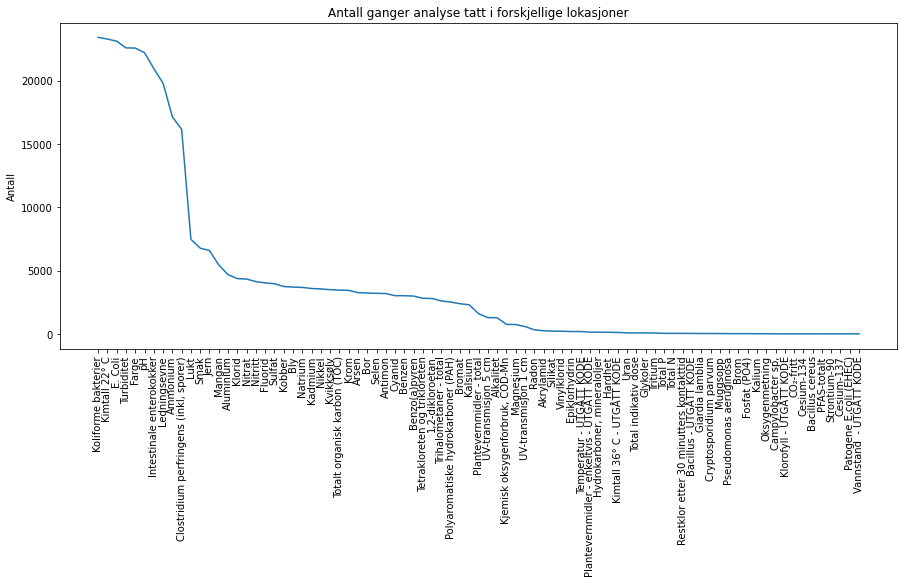

In [12]:
plt.figure(figsize=(15,6))
plt.plot(fil.analysetype.value_counts())
plt.xticks(fil.analysetype.value_counts().index, rotation=90)
plt.title('Antall ganger analyse tatt i forskjellige lokasjoner')
plt.ylabel('Antall');

#### Ser på total antalle analyse typer

In [13]:
total_antall_analyser = fil.groupby('analysetype').sum().reset_index()[['analysetype','ant_analyser']].sort_values('ant_analyser', ascending=False)
total_antall_analyser

,analysetype,ant_analyser
42,Koliforme bakterier,699171.0
36,Kimtall 22° C,690856.0
76,Turbiditet,601643.0
24,Farge,589855.0
22,E. Coli,577020.0
82,pH,508255.0
31,Intestinale enterokokker,313621.0
45,Ledningsevne,279006.0
46,Lukt,143589.0
65,Smak,127326.0


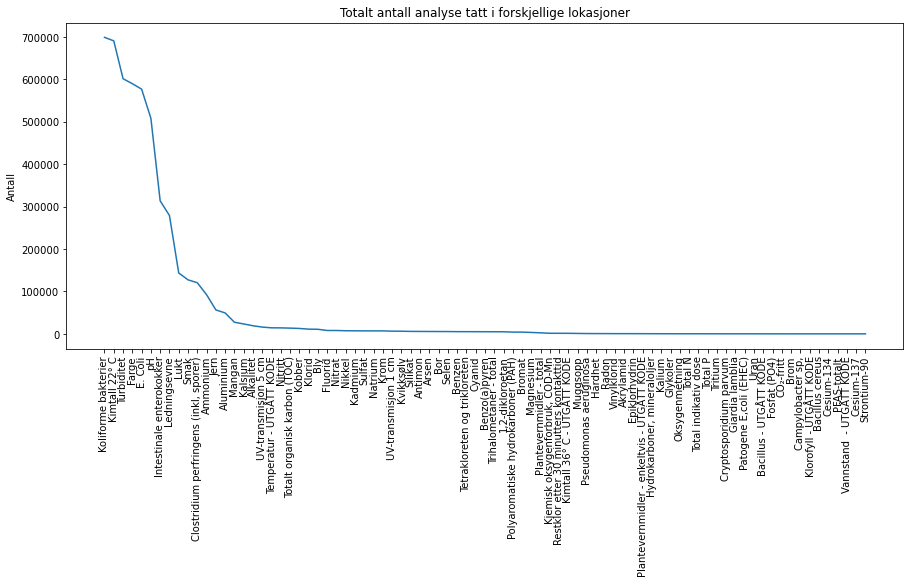

In [14]:
plt.figure(figsize=(15,6))
plt.plot(total_antall_analyser['analysetype'], total_antall_analyser['ant_analyser'])
plt.xticks(total_antall_analyser['analysetype'], rotation=90)
plt.title('Totalt antall analyse tatt i forskjellige lokasjoner')
plt.ylabel('Antall');

#### Vi ser på alle analyser som har vist mer enn eller lik 20

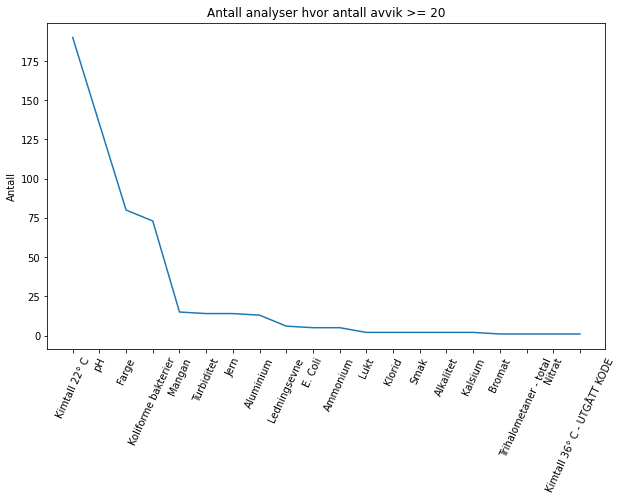

In [15]:
mest_avvik = fil.loc[fil.ant_avvik >= 20]
plt.figure(figsize=(10,6))
plt.plot(mest_avvik.analysetype.value_counts())
plt.xticks(mest_avvik.analysetype.value_counts().index, rotation=65)
plt.title('Antall analyser hvor antall avvik >= 20')
plt.ylabel('Antall');

Type analyser som blir utført er interessant data og undersøke og det er mye som må/bør gjøres der. Men det virker for meg at det type analyse er noe som forhåndbestemmes etter at avgjørelsen for å ta analyser har blitt tatt.

### Setter sammen filene for å starte treningen

In [16]:
fil2 = pd.read_excel('2020 Vannforsyningssystem data.xlsx')

In [17]:
data = fil.merge(fil2, how='left', on=['mtid_vf', 'periode'])

In [18]:
data.head()

,mtid_vf,periode,analysetype,ant_krav,ant_analyser,ant_avvik,aktiv,kommune,mtregion,vannprod,beredskap,beredsk_oppd,beredsk_ovelse,forbr_fast_bosetting,forbr_fritidsboliger,forbr_industri,forbr_tjytende,forbr_primnaering,forbr_annet,forbr_lekkasje
0,Z0704301334229761190PVHZK,2011,Smak,4.0,4.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Z0704301334229761190PVHZK,2011,Koliforme bakterier,12.0,12.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Z0704301334229761190PVHZK,2011,"Clostridium perfringens (inkl, sporer)",5.0,5.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Z0704301334229761190PVHZK,2011,Kimtall 22° C,12.0,12.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Z0704301334229761190PVHZK,2011,Lukt,4.0,4.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


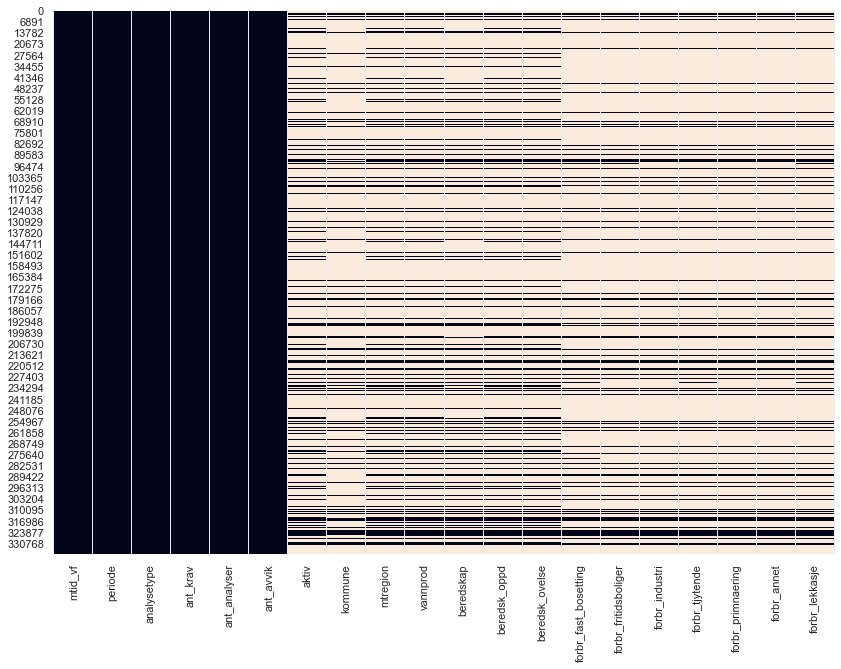

In [19]:
sns.set(rc={'figure.figsize':(14,10)})
sns.heatmap(data.isna(), cbar=False);

In [20]:
data.columns

Index(['mtid_vf', 'periode', 'analysetype', 'ant_krav', 'ant_analyser',
       'ant_avvik', 'aktiv', 'kommune', 'mtregion', 'vannprod', 'beredskap',
       'beredsk_oppd', 'beredsk_ovelse', 'forbr_fast_bosetting',
       'forbr_fritidsboliger', 'forbr_industri', 'forbr_tjytende',
       'forbr_primnaering', 'forbr_annet', 'forbr_lekkasje'],
      dtype='object')

In [21]:
data = data[['ant_analyser', 'vannprod', 'beredskap',
       'beredsk_oppd', 'beredsk_ovelse', 'ant_avvik']].dropna()

#### Magnlende data i datasettet etter fjerning av null-verider

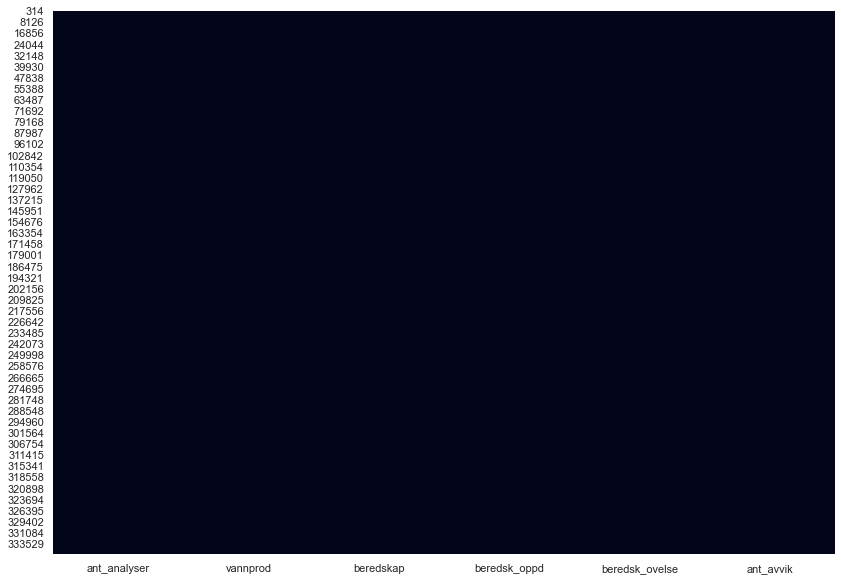

In [22]:
sns.set(rc={'figure.figsize':(14,10)})
sns.heatmap(data.isna(), cbar=False);

In [23]:
print(f"Antall rader i datasettet: {len(data)}")

Antall rader i datasettet: 67523


Text(0.5, 1.0, 'Antall avvik')

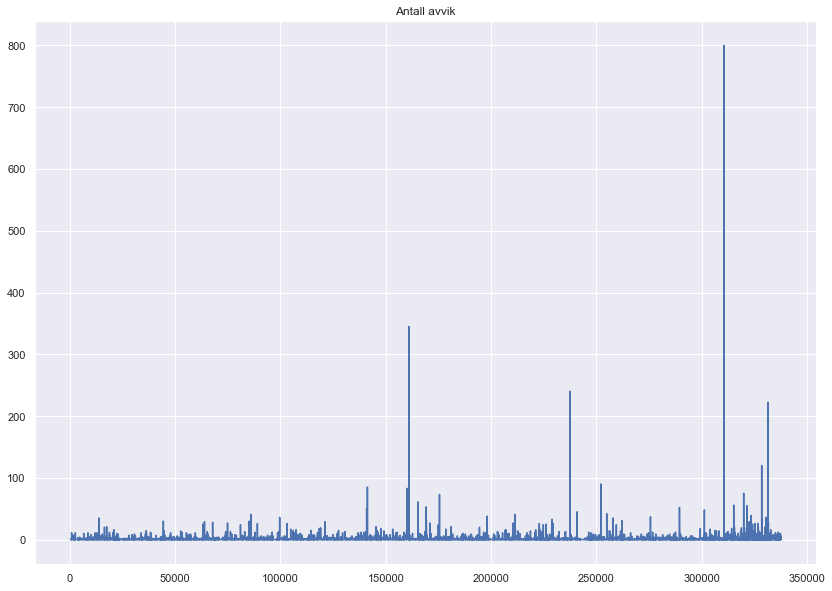

In [24]:
data.ant_avvik.plot()
plt.title('Antall avvik')

In [25]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 67523 entries, 314 to 337644
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ant_analyser    67523 non-null  float64
 1   vannprod        67523 non-null  float64
 2   beredskap       67523 non-null  object 
 3   beredsk_oppd    67523 non-null  object 
 4   beredsk_ovelse  67523 non-null  object 
 5   ant_avvik       67523 non-null  float64
dtypes: float64(3), object(3)
memory usage: 3.6+ MB


#### Vi ser på kategoriske variabler og transformere de til heletall

In [26]:
print(f"beredskap kolonnen: {data.beredskap.unique()}")
print(f"beredsk_oppd kolonnen: {data.beredsk_oppd.unique()}")
print(f"beredsk_ovelse kolonnen: {data.beredsk_ovelse.unique()}")

beredskap kolonnen: ['ja' 'nei']
beredsk_oppd kolonnen: ['ja' 'nei']
beredsk_ovelse kolonnen: ['ja' 'nei']


In [27]:
data['beredskap'] = data['beredskap'].astype('category')
data['beredskap_transformert'] = data['beredskap'].cat.codes
data['beredsk_oppd'] = data['beredsk_oppd'].astype('category')
data['beredsk_oppd_t'] = data['beredsk_oppd'].cat.codes
data['beredsk_ovelse'] = data['beredsk_ovelse'].astype('category')
data['beredsk_ovelse_t'] = data['beredsk_ovelse'].cat.codes

In [28]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 67523 entries, 314 to 337644
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   ant_analyser            67523 non-null  float64 
 1   vannprod                67523 non-null  float64 
 2   beredskap               67523 non-null  category
 3   beredsk_oppd            67523 non-null  category
 4   beredsk_ovelse          67523 non-null  category
 5   ant_avvik               67523 non-null  float64 
 6   beredskap_transformert  67523 non-null  int8    
 7   beredsk_oppd_t          67523 non-null  int8    
 8   beredsk_ovelse_t        67523 non-null  int8    
dtypes: category(3), float64(3), int8(3)
memory usage: 2.4 MB


Jeg standariserer ikke data. Grunnen er at jeg kan ikke standarisere før trening/testing deling. Etter deling kan standarisering føre til skje fordelinger...

### Maskinlæringsmodeller

- Deler data i trening og test, henholdsvis 80-20
- Undersøker og sammenligner noen maskinlæringsmodeller på datasettet

In [29]:
trening, test = train_test_split(data, test_size=0.2)

In [30]:
print(f"Antall trenings data: {len(trening)}")
print(f"Antall test data: {len(test)}")

Antall trenings data: 54018
Antall test data: 13505


#### Setter opp for trening av flere modeller

In [40]:
clf = setup(trening, target='ant_avvik', session_id=42, log_experiment=True, experiment_name='Avvik', silent=True)

,Description,Value
0,session_id,42
1,Target,ant_avvik
2,Target Type,Multiclass
3,Label Encoded,None
4,Original Data,"(54018, 9)"
5,Missing Values,False
6,Numeric Features,5
7,Categorical Features,3
8,Ordinal Features,False
9,High Cardinality Features,False


#### Sammenligner modeller

Sammenligner alle modellene som ble trent og velger de 5 med høyest score

In [41]:
modeller = compare_models(n_select=5)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
knn,K Neighbors Classifier,0.9430,0.0000,0.0679,0.9109,0.9195,0.0868,0.1540,0.1630
lr,Logistic Regression,0.9426,0.0000,0.0461,0.8885,0.9147,0.0000,0.0000,19.5190
ridge,Ridge Classifier,0.9424,0.0000,0.0462,0.8894,0.9148,0.0035,0.0145,0.0130
xgboost,Extreme Gradient Boosting,0.9420,0.0000,0.0836,0.9101,0.9188,0.0846,0.1416,4.4380
catboost,CatBoost Classifier,0.9417,0.0000,0.0459,0.8968,0.9154,0.0227,0.0565,53.6790
ada,Ada Boost Classifier,0.9354,0.0000,0.0448,0.8881,0.9111,-0.0045,-0.0052,0.5900
lda,Linear Discriminant Analysis,0.9352,0.0000,0.0336,0.8916,0.9128,0.0476,0.0658,0.0110
et,Extra Trees Classifier,0.9335,0.0000,0.0840,0.9086,0.9194,0.1657,0.1826,0.2920
dt,Decision Tree Classifier,0.9319,0.0000,0.0844,0.9082,0.9188,0.1698,0.1833,0.0110
rf,Random Forest Classifier,0.9317,0.0000,0.0921,0.9081,0.9186,0.1669,0.1803,0.2910


In [42]:
plot_types = ['auc', 'threshold', 'pr', 'confusion_matrix', 'error', 'class_report', 'boundary', 
              'learning', 'calibration', 'vc', 'feature', 'gain']
def plot_util(models, plot, title='Sammenligning av modeller'):
    imgs = []
    for model in models:
        try: imgs.append(plt.imread(plot_model(model, plot=plot, save=True)))
        except: imgs.append(np.ones((1100, 1600, 4)))

    n_rows, n_cols = len(imgs)//2, 2
    fig, axs = plt.subplots(n_rows, n_cols, figsize=(n_cols*7, n_rows*4))
    fig.suptitle(title, fontsize=12, y=0.89)
    
    for r in range(n_rows):
        for c in range(n_cols):
            i = r*n_cols+c
            plt.subplot(n_rows, n_cols, i+1)
            plt.imshow(imgs[i])
            plt.axis('off')
    fig.subplots_adjust(wspace=0, hspace=0)

In [31]:
from sklearn.svm import LinearSVR
svm_reg = LinearSVR(epsilon=1.5)
X = trening[['ant_analyser', 'vannprod', 'beredskap_transformert', 'beredsk_oppd_t', 'beredsk_ovelse_t']]
y = trening[['ant_avvik']]
svm_reg.fit(X, y)

LinearSVR(epsilon=1.5)

In [33]:
X_test = test[['ant_analyser', 'vannprod', 'beredskap_transformert', 'beredsk_oppd_t', 'beredsk_ovelse_t']]
y_test = test[['ant_avvik']]

In [35]:
y_pred = svm_reg.predict(X_test)

In [36]:
t_ = np.arange(len(y_pred))

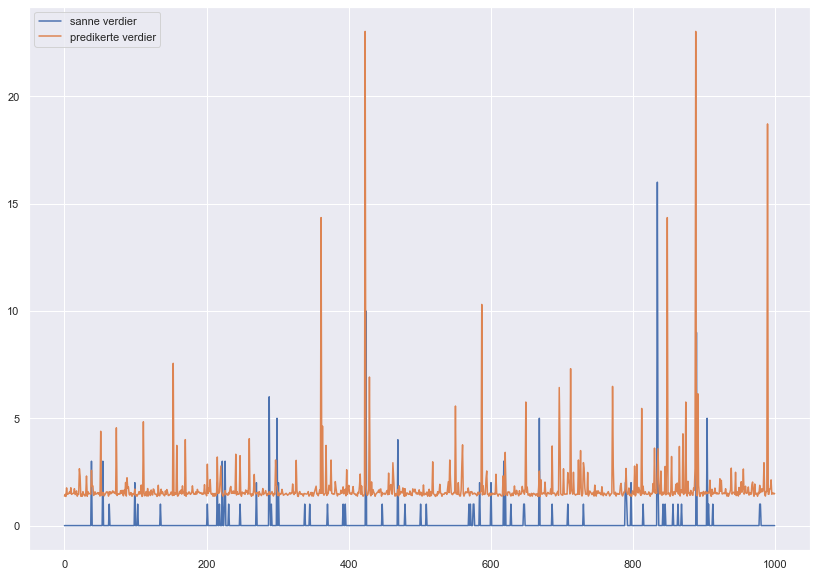

In [44]:
max_ant = 1000
plt.plot(t_[:max_ant], y_test[:max_ant], label='sanne verdier')
plt.plot(t_[0:max_ant], y_pred[:max_ant], label='predikerte verdier')
plt.legend()